# Environment

## Imports

In [1]:
import pyranges1 as pr
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from collections import Counter
import itertools

## Global variables

## Load data

Load peaks

In [27]:
filepath = "data/peaks/screen.bed"
screen_peaks = pr.read_bed(filepath)
screen_peaks.head()

,Chromosome,Start,End,Name,Score,Strand
0,chr1,10033,10250,EH38D4327497,EH38E2776516,pELS
1,chr1,10385,10713,EH38D4327498,EH38E2776517,pELS
2,chr1,16097,16381,EH38D6144701,EH38E3951272,CA-CTCF
3,chr1,17343,17642,EH38D6144702,EH38E3951273,CA-TF
4,chr1,29320,29517,EH38D6144703,EH38E3951274,CA


In [2]:
filepath = "data/peaks/newlvl5_consensus_peaks.bed"
peaks = pr.read_bed(filepath)
peaks["Center"] = peaks["Start"] + (peaks["End"] - peaks["Start"]) // 2
peaks["celltypes"] = peaks["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
peaks["ct_count"] = peaks["celltypes"].apply(lambda x: int(len(set(x.split(",")))))
peaks.head()

,Chromosome,Start,End,Name,Score,Strand,Center,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,794945,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,804926,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,833908,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,841923,megakaryocyte_progenitor,1


Load cell type annotations

In [3]:
annotation = pd.read_csv("data/annotations/we_new_lvl5.csv")
annotation["celltype"] = annotation["celltype"].str.replace(" ", "_").str.lower()
annotation.head()

,sample_id,barcode,celltype
0,WS_wEMB13386878,ATGGACAAGACAGGTA-1,chondrocyte_precursor
1,WS_wEMB13386878,TCAAGTATCTGTGAGT-1,yolk_sac-derived_trem2+_macrophage
2,WS_wEMB13386878,CGGCTCACAGTTATGT-1,early_endothelium
3,WS_wEMB13386878,ATTTGCGCACTAAGCC-1,fibroblast_progenitors_pdgfra+zic1+fibin+
4,WS_wEMB13386878,CCTTCAATCAAGCTTA-1,monocyte


Load tss annotation

In [4]:
tss = pr.read_bed("data/genome/hg38_pycistopic_tss.bed")
tss.head()

,Chromosome,Start,End,Name,Score,Strand,ThickStart
0,chrM,3306,3307,MT-ND1,.,+,protein_coding
1,chrM,4469,4470,MT-ND2,.,+,protein_coding
2,chrM,5903,5904,MT-CO1,.,+,protein_coding
3,chrM,7585,7586,MT-CO2,.,+,protein_coding
4,chrM,8365,8366,MT-ATP8,.,+,protein_coding


# Analyze peaks

## Number of cells per cell type

/tmp/ipykernel_2278391/3727745538.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


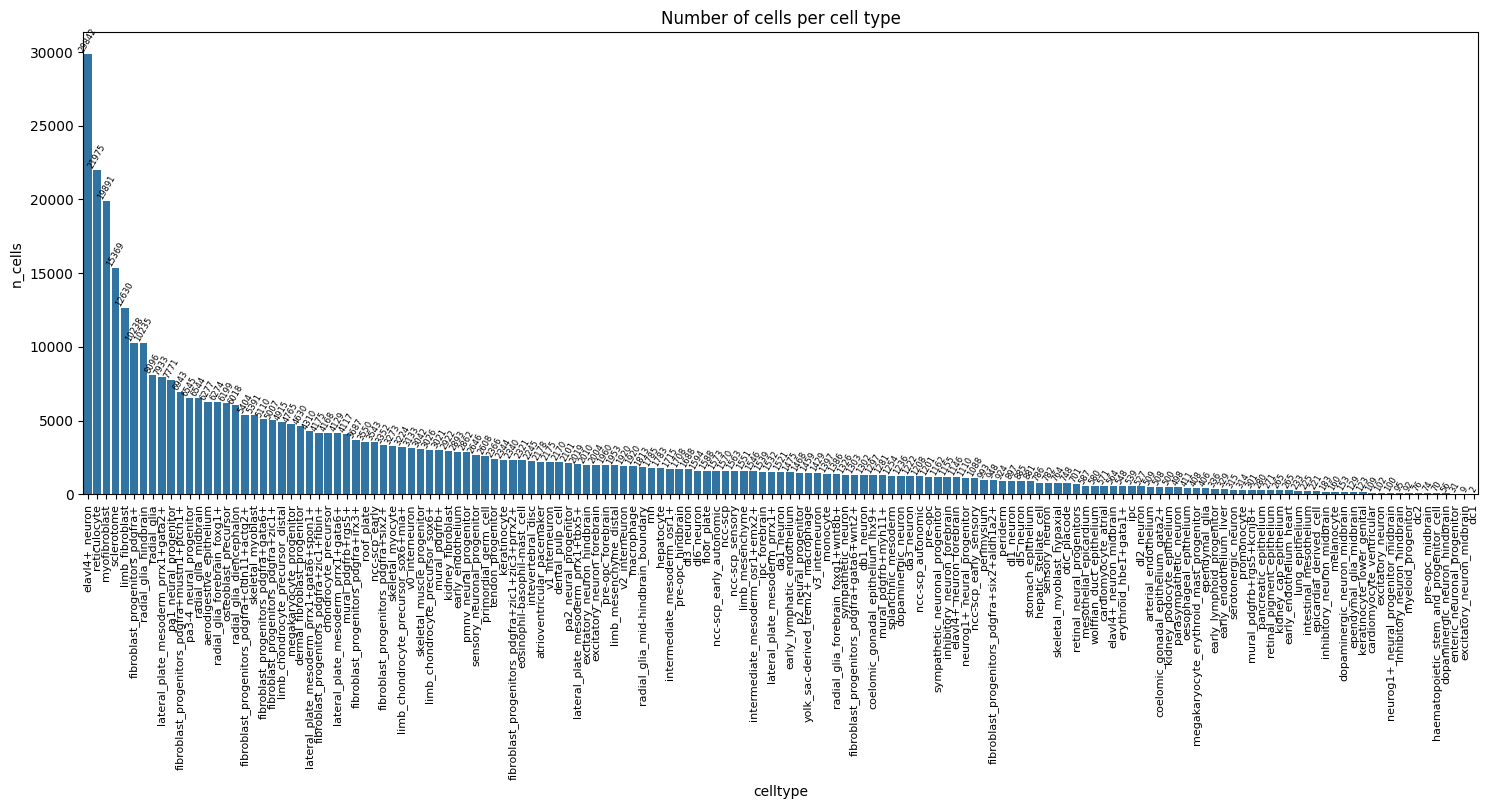

In [5]:
fig, ax = plt.subplots(figsize=(18, 6))
cell_counts = annotation.celltype.str.replace(" ", "_").str.lower().value_counts().to_frame(name="n_cells")

sns.barplot(cell_counts, x=cell_counts.index, y="n_cells", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=6, rotation=60);
plt.show()

## Peak counts

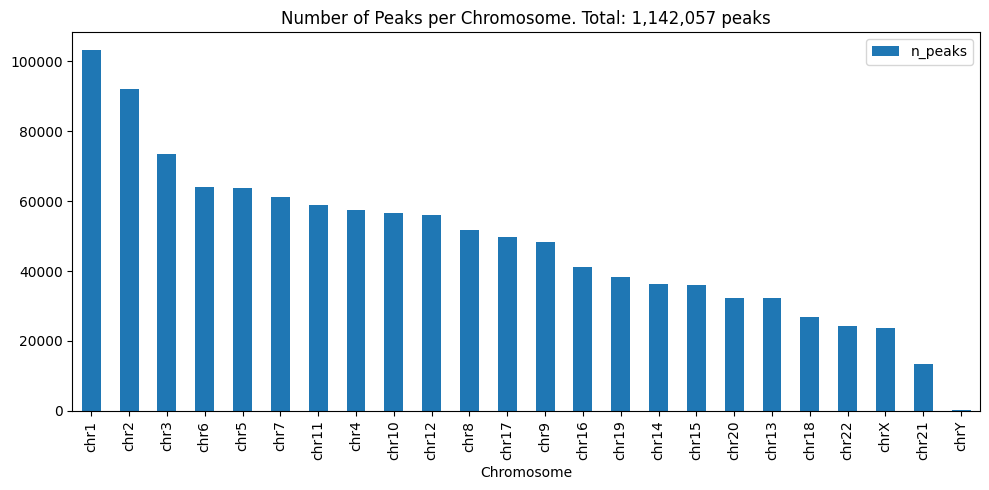

In [6]:
peak_number_by_chr = peaks.Chromosome.value_counts().to_frame(name="n_peaks").reset_index()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_number_by_chr['Chromosome'] = peak_number_by_chr['Chromosome'].astype(cat_type)

peak_number_by_chr.plot.bar(x='Chromosome', y='n_peaks', figsize=(10, 5))
plt.title(f'Number of Peaks per Chromosome. Total: {peaks.shape[0]:,} peaks')
plt.tight_layout()

Let's take a look at peak numbers per cell type

In [7]:
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks["celltypes"].tolist()]))
counts = Counter(flat)
n_peaks_celltype = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks"]).set_index("celltype")

/tmp/ipykernel_2278391/2239745134.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


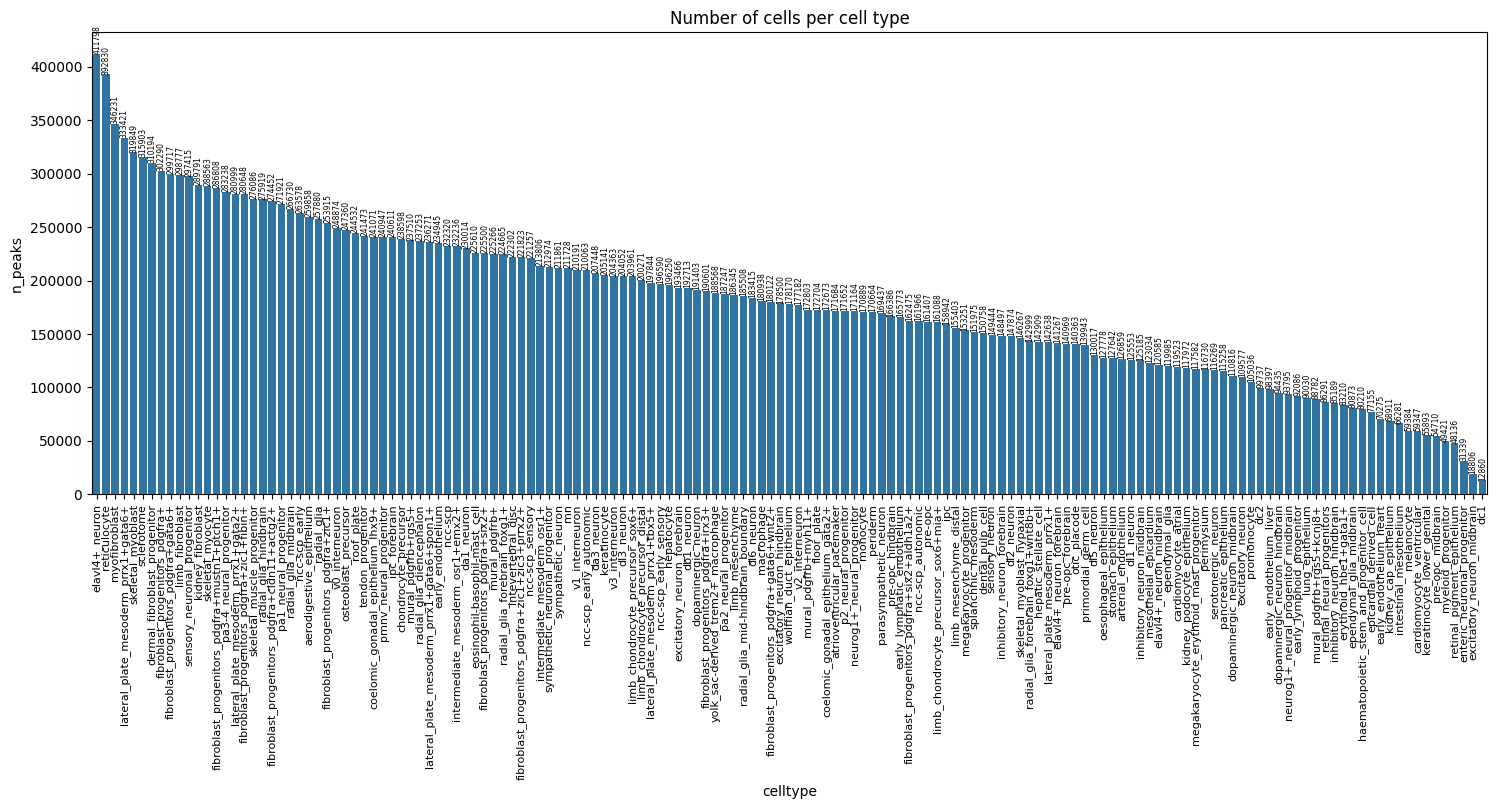

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.barplot(n_peaks_celltype.reset_index(), x="celltype", y="n_peaks", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=5.5, rotation=90);
plt.show()

Let's also take a look at peak numbers per chromosome

In [9]:
celltypes = cell_counts.index.tolist()

In [10]:
peak_number_by_chr = peaks.Chromosome.value_counts().to_frame(name="n_peaks").reset_index()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_number_by_chr['Chromosome'] = peak_number_by_chr['Chromosome'].astype(cat_type)

In [11]:
ct_peak_numbers = list()
for ct in tqdm(celltypes, desc="Calculating peaks per cell type"):
    subset = peaks[peaks.celltypes.str.contains(ct, regex=False)]
    peak_number_by_chr = subset.Chromosome.value_counts().to_frame(name=ct)
    ct_peak_numbers.append(peak_number_by_chr)

ct_peak_numbers_df = pd.concat(ct_peak_numbers, axis=1).fillna(0)
ct_peak_numbers_df

Calculating peaks per cell type:   0%|          | 0/151 [00:00<?, ?it/s]

,elavl4+_neuron,reticulocyte,myofibroblast,sclerotome,limb_fibroblast,fibroblast_progenitors_pdgfra+,radial_glia_hindbrain,radial_glia,lateral_plate_mesoderm_prrx1+gata2+,pa1_neural_progenitor,...,neurog1+_neural_progenitor_midbrain,inhibitory_neuron_hindbrain,myeloid_progenitor,dc2,pre-opc_midbrain,haematopoietic_stem_and_progenitor_cell,dopaminergic_neuron_hindbrain,enteric_neuronal_progenitor,excitatory_neuron_midbrain,dc1
Chromosome,,,,,,,,,,,,,,,,,,,,,
chr1,41800,37458,33609,29441,28923,53826,25853,41961,26742,26383,...,9197,8344,5077,9703,5438,8312,9322,3152,1975,1258
chr2,32806,28667,24252,22986,21234,42414,19743,32634,20973,18463,...,6630,5935,3200,6805,3798,5202,6634,2138,1263,904
chr3,24867,21927,18681,17425,16098,33481,15087,25481,15491,14253,...,4756,4251,2330,5266,2670,3951,4868,1624,1065,744
chr11,24696,22097,19787,17523,17009,31379,15486,24858,15384,15967,...,5291,4956,2794,5543,3078,4574,5439,1801,1051,725
chr17,24304,22260,21129,18208,17770,30821,15728,24305,15390,16556,...,5590,5167,3397,6630,3419,5482,5675,2065,1187,871
chr7,23160,20472,17907,16693,15565,29583,14562,23758,14947,14032,...,4844,4376,2470,4826,2739,3972,4916,1525,914,613
chr6,22515,19671,16500,16157,14153,29395,13897,22679,14179,12573,...,4590,3916,2455,5370,2802,3979,4520,1560,1052,705
chr5,22111,19225,16178,15255,14097,28993,13092,22233,13830,12434,...,4515,3883,2210,4249,2519,3308,4509,1413,847,594
chr10,22002,19425,16864,15560,14795,28008,12650,20895,13730,12613,...,4317,4023,2123,4491,2448,3528,4339,1326,768,572


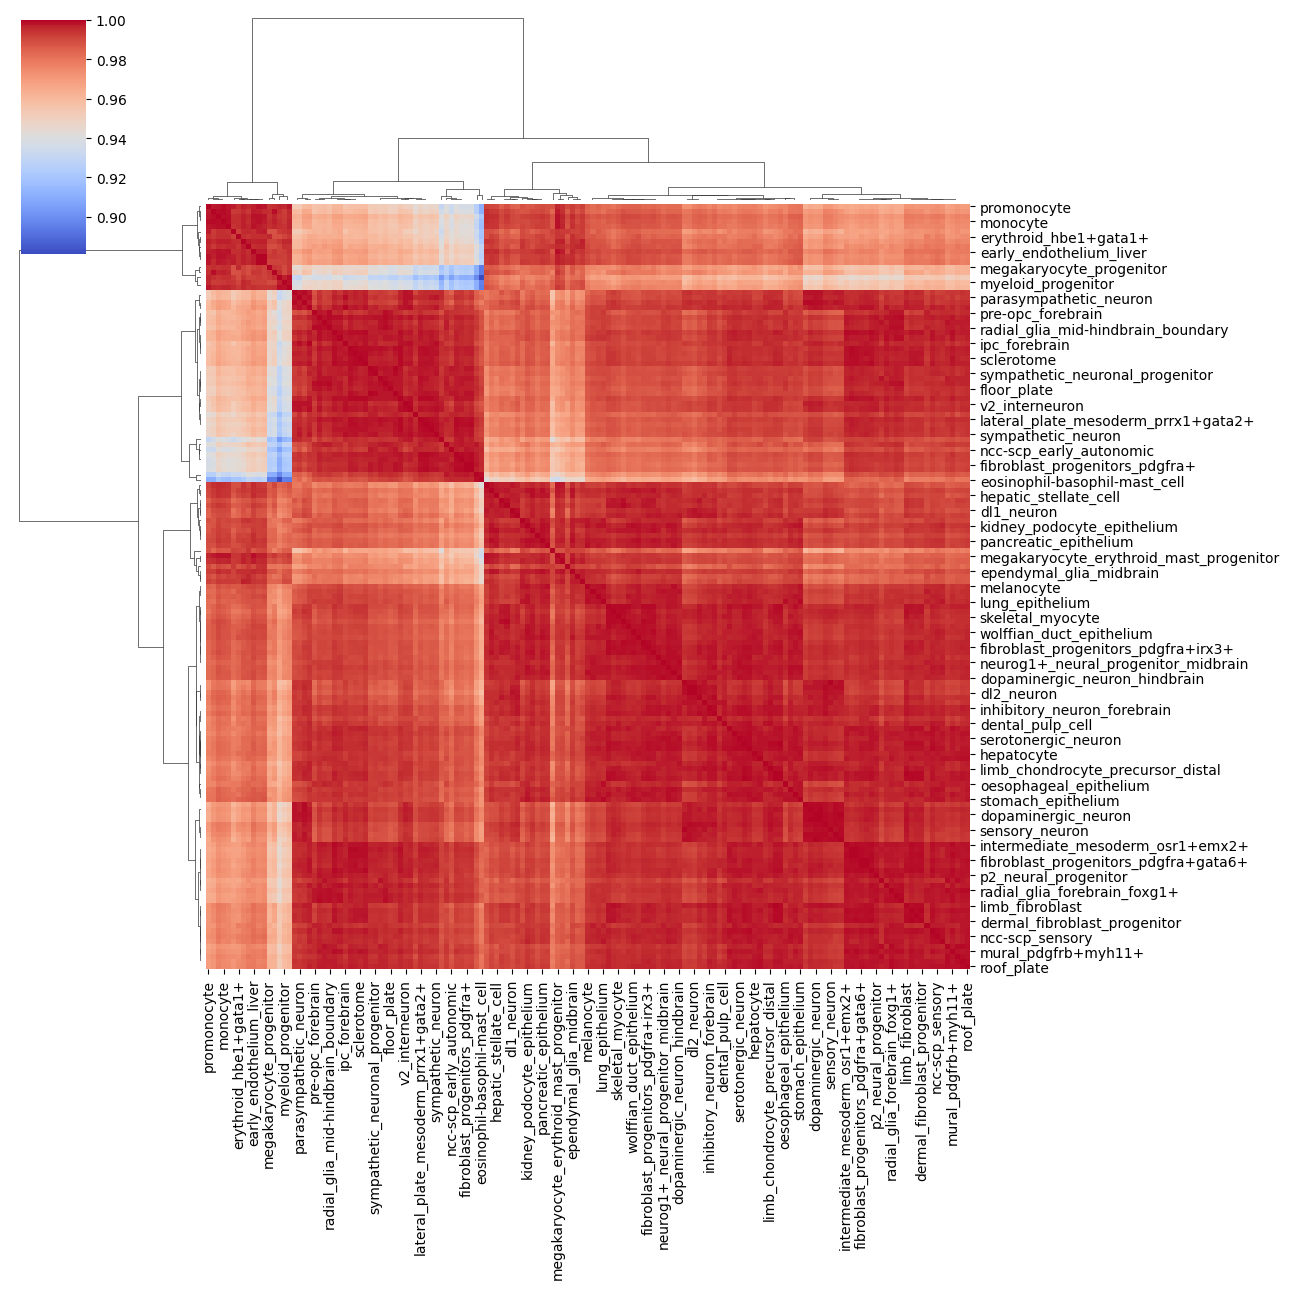

In [12]:
sns.clustermap(ct_peak_numbers_df.corr(), cmap="coolwarm", metric="cosine", figsize=(13, 13), cbar_kws={"shrink": 0.8})
plt.show()

## Shared peaks

It's interesting to see how often peaks are shared between cell types

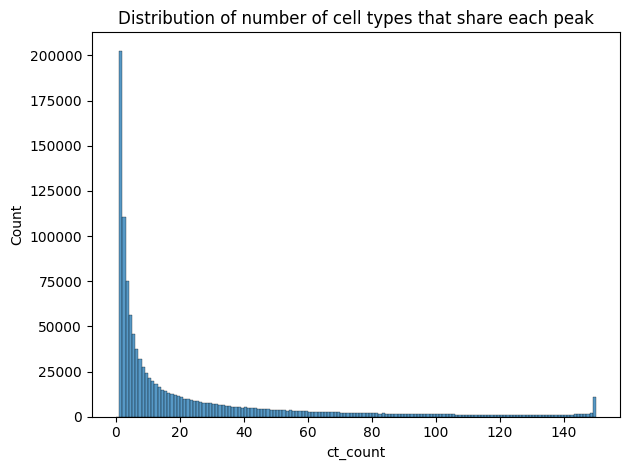

In [13]:
sns.histplot(peaks.ct_count, bins=np.arange(0, len(celltypes), 1))
plt.title("Distribution of number of cell types that share each peak")
plt.tight_layout()

In [14]:
print(f"Number of peaks that are present in 1 cell type: {(peaks['ct_count'] == 1).sum()}")
print(f"Number of peaks that are present in 3 or fewer cell types: {(peaks['ct_count'] <= 3).sum()}")
print(f"Number of peaks that are present in more than 3 cell types: {(peaks['ct_count'] > 3).sum()}")

Number of peaks that are present in 1 cell type: 202682
Number of peaks that are present in 3 or fewer cell types: 388195
Number of peaks that are present in more than 3 cell types: 753862


Let's take a look at number peaks per celltype

In [15]:
peaks.head()

,Chromosome,Start,End,Name,Score,Strand,Center,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,794945,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,804926,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,833908,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,841923,megakaryocyte_progenitor,1


In [16]:
# count the number of peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_counts = peaks[peaks['ct_count'] == 1].celltypes.value_counts().to_frame(name="n_unique")

peak_counts = pd.concat([
    n_peaks_celltype,
    unique_peak_counts,
    cell_counts,
    ], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique"] = peak_counts["n_unique"] / peak_counts["n_peaks"]
peak_counts

,celltype,n_peaks,n_unique,n_cells,frc_unique
0,elavl4+_neuron,411798,138,29842,0.000335
1,reticulocyte,392830,170,21975,0.000433
2,myofibroblast,346231,165,19891,0.000477
5,sclerotome,315903,2460,15369,0.007787
9,limb_fibroblast,298777,738,12630,0.002470
...,...,...,...,...,...
137,haematopoietic_stem_and_progenitor_cell,80210,4040,70,0.050368
128,dopaminergic_neuron_hindbrain,94435,3548,56,0.037571
148,enteric_neuronal_progenitor,31339,494,31,0.015763
149,excitatory_neuron_midbrain,18806,354,9,0.018824


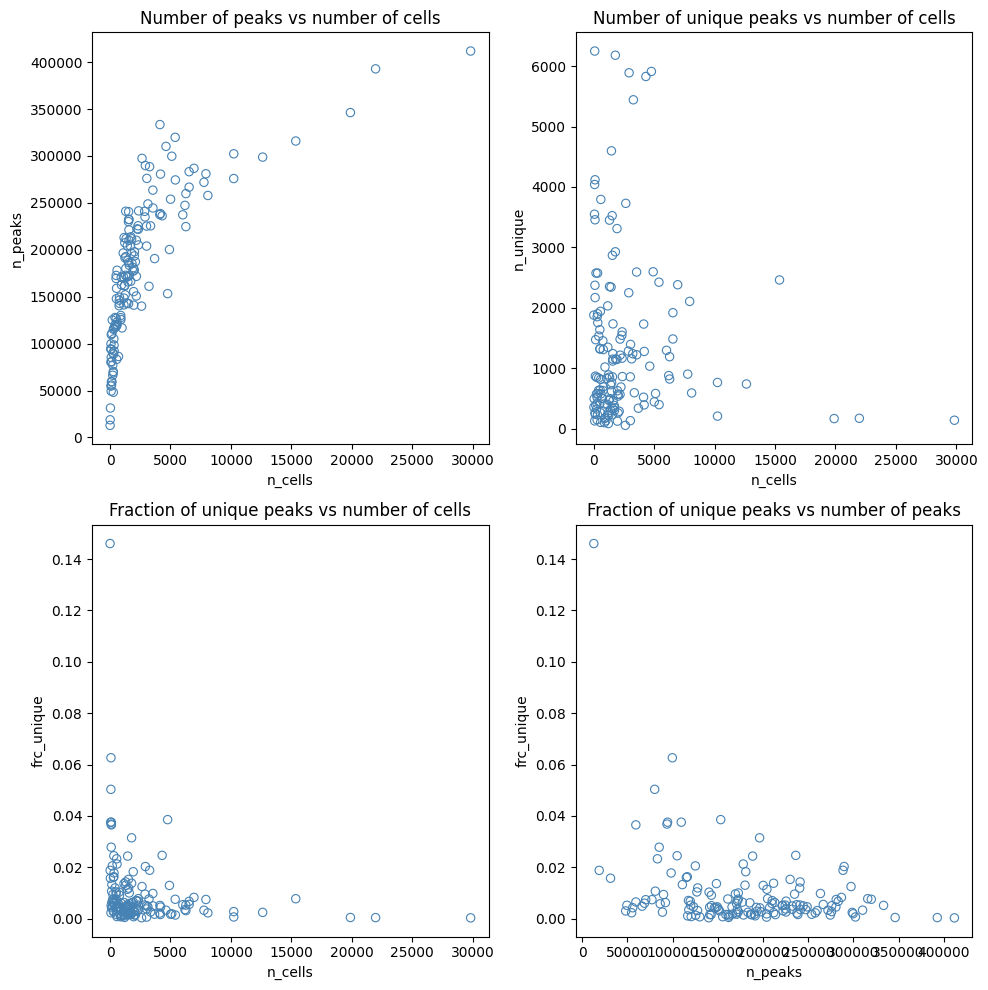

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

scatter_kws = dict(facecolors='none', edgecolors='steelblue', linewidth=0.8)

sns.scatterplot(peak_counts, x="n_cells", y="n_peaks", ax=axes[0, 0], **scatter_kws)
axes[0, 0].set_title("Number of peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="n_unique", ax=axes[0, 1], **scatter_kws)
axes[0, 1].set_title("Number of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="frc_unique", ax=axes[1, 0], **scatter_kws)
axes[1, 0].set_title("Fraction of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_peaks", y="frc_unique", ax=axes[1, 1], **scatter_kws)
axes[1, 1].set_title("Fraction of unique peaks vs number of peaks")

plt.tight_layout()

## Scores

In [18]:
av_score_ct = dict()
median_score_ct = dict()
for ct in tqdm(celltypes):
    subset = peaks[peaks.celltypes.str.contains(ct, regex=False)]
    av_score_ct[ct] = subset.Score.mean()
    median_score_ct[ct] = subset.Score.median()

  0%|          | 0/151 [00:00<?, ?it/s]

In [19]:
# count the number of peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_counts = peaks[peaks['ct_count'] == 1].celltypes.value_counts().to_frame(name="n_unique")

peak_counts = pd.concat([
    n_peaks_celltype,
    unique_peak_counts,
    cell_counts,
    pd.DataFrame(median_score_ct, index=["median_score"]).T,
    pd.DataFrame(av_score_ct, index=["mean_score"]).T
    ], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique"] = peak_counts["n_unique"] / peak_counts["n_peaks"]
peak_counts

,celltype,n_peaks,n_unique,n_cells,median_score,mean_score,frc_unique
0,elavl4+_neuron,411798,138,29842,5.386101,12.706205,0.000335
1,reticulocyte,392830,170,21975,5.377473,12.570463,0.000433
2,myofibroblast,346231,165,19891,5.492472,13.197194,0.000477
5,sclerotome,315903,2460,15369,5.451761,13.558044,0.007787
9,limb_fibroblast,298777,738,12630,5.988476,14.228549,0.002470
...,...,...,...,...,...,...,...
137,haematopoietic_stem_and_progenitor_cell,80210,4040,70,17.091588,32.286451,0.050368
128,dopaminergic_neuron_hindbrain,94435,3548,56,15.889047,29.700055,0.037571
148,enteric_neuronal_progenitor,31339,494,31,51.435690,59.007073,0.015763
149,excitatory_neuron_midbrain,18806,354,9,73.028281,75.285058,0.018824


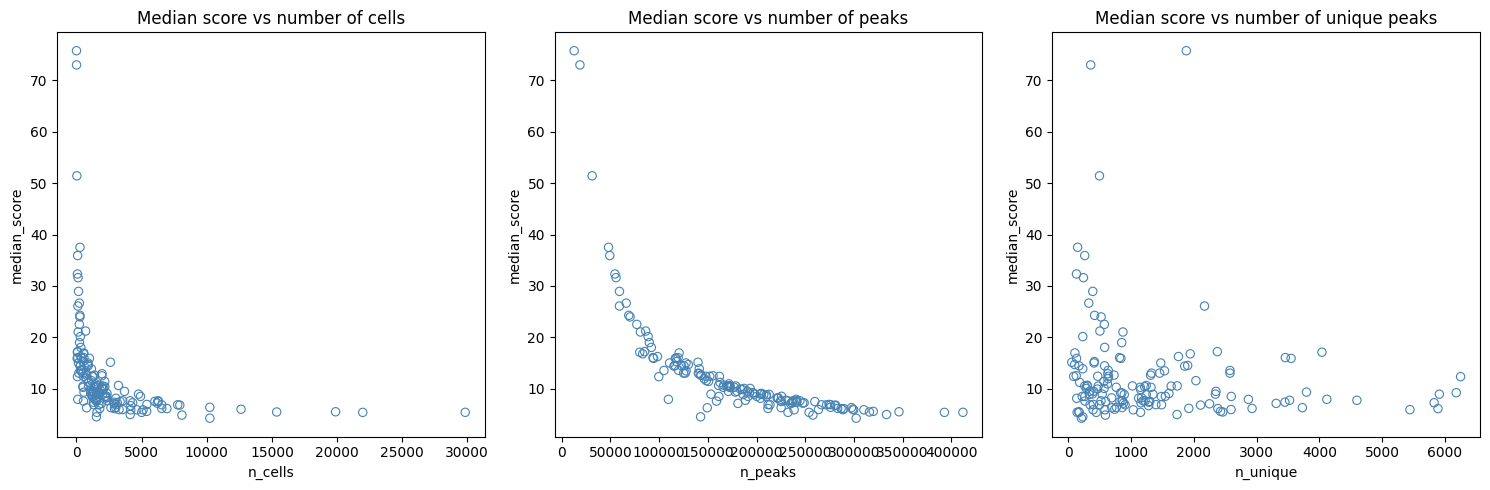

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(peak_counts, x="n_cells", y="median_score", ax=axes[0], **scatter_kws)
axes[0].set_title("Median score vs number of cells")

sns.scatterplot(peak_counts, x="n_peaks", y="median_score", ax=axes[1], **scatter_kws)
axes[1].set_title("Median score vs number of peaks")

sns.scatterplot(peak_counts, x="n_unique", y="median_score", ax=axes[2], **scatter_kws)
axes[2].set_title("Median score vs number of unique peaks")

plt.tight_layout()

## TSS distance

In [21]:
peaks_tss = peaks.nearest_ranges(tss, suffix="_tss")
peaks_tss["log_distance"] = np.log1p(peaks_tss.Distance)
peaks_tss.head()

/tmp/ipykernel_2278391/2204458230.py:1: UserWarning: nearest_ranges: 'auto' strand_behavior treated as ignore due to invalid Strand values. Please use strand_behavior=ignore
  peaks_tss = peaks.nearest_ranges(tss, suffix="_tss")


,Chromosome,Start,End,Name,Score,Strand,Center,celltypes,ct_count,Chromosome_tss,Start_tss,End_tss,Name_tss,Score_tss,Strand_tss,ThickStart_tss,Distance,log_distance
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,794945,radial_glia_diencephalon,1,chr1,686653,686654,OR4F16,.,-,protein_coding,108042,11.590285
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,804926,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1,chr1,686653,686654,OR4F16,.,-,protein_coding,118023,11.678643
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1,chr1,923922,923923,SAMD11,.,+,protein_coding,90386,11.411856
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,833908,megakaryocyte_progenitor,1,chr1,923922,923923,SAMD11,.,+,protein_coding,89765,11.404962
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,841923,megakaryocyte_progenitor,1,chr1,923922,923923,SAMD11,.,+,protein_coding,81750,11.311433


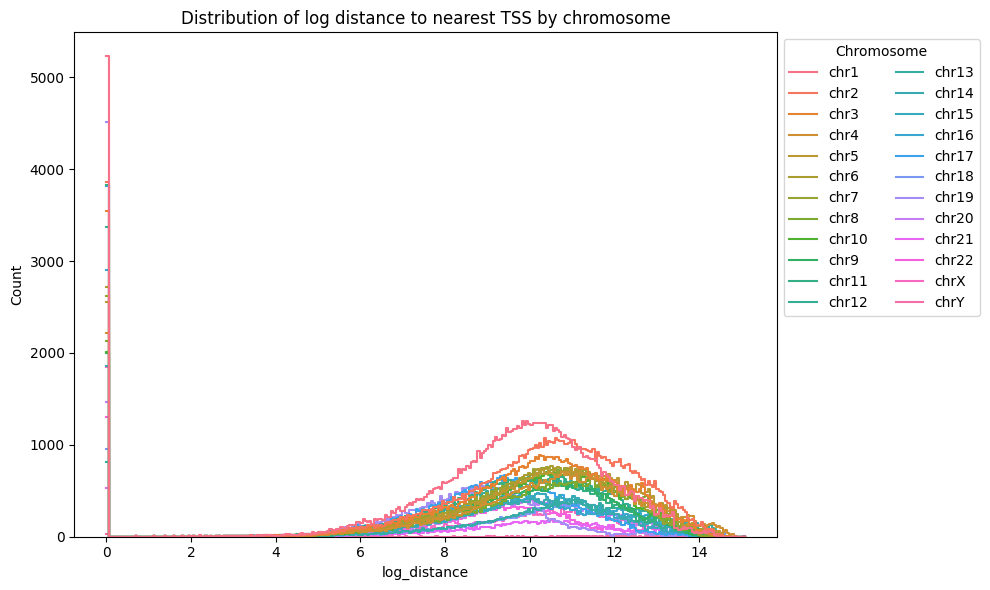

In [22]:
fig = plt.figure(figsize=(10, 6))
ax = sns.histplot(peaks_tss, x="log_distance", hue="Chromosome", element="step", fill=False)
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 1), title="Chromosome", ncol=2)
plt.title("Distribution of log distance to nearest TSS by chromosome")
plt.tight_layout()

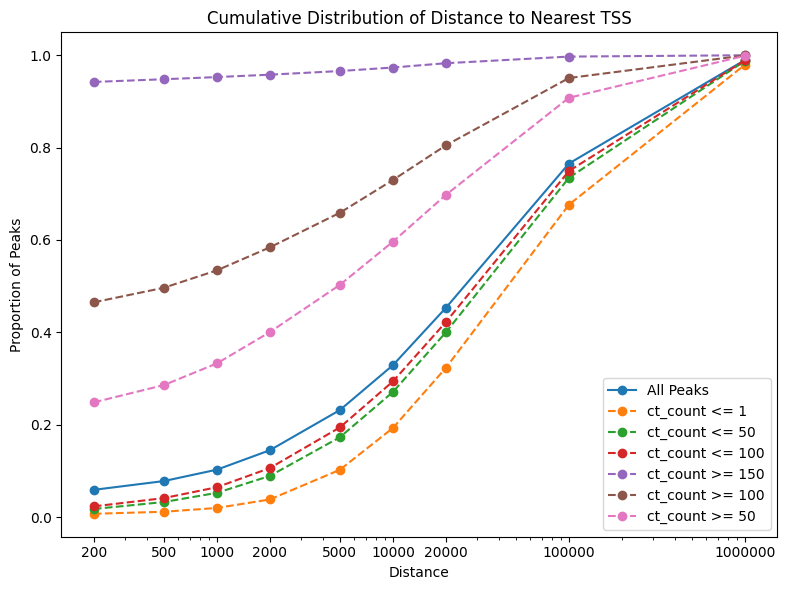

In [23]:
fig = plt.figure(figsize=(8, 6))

distance = [200, 500, 1000, 2000, 5000, 10000, 20000, 100000, 1000000]
ct_counts_less = [1, 50, 100]
ct_count_greater = [150, 100, 50]
plt.plot(distance, [(peaks_tss.Distance <= d).mean() for d in distance], 'o-', label="All Peaks")
for ct in ct_counts_less:
    plt.plot(distance, [(peaks_tss[peaks_tss.ct_count <= ct].Distance <= d).mean() for d in distance], 'o--', label=f"ct_count <= {ct}")
for ct in ct_count_greater:
    plt.plot(distance, [(peaks_tss[peaks_tss.ct_count >= ct].Distance <= d).mean() for d in distance], 'o--', label=f"ct_count >= {ct}")
plt.xscale("log")
plt.xticks(ticks=distance, labels=distance)
plt.xlabel("Distance")
plt.ylabel("Proportion of Peaks")
plt.title("Cumulative Distribution of Distance to Nearest TSS")
plt.legend()
plt.tight_layout()

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

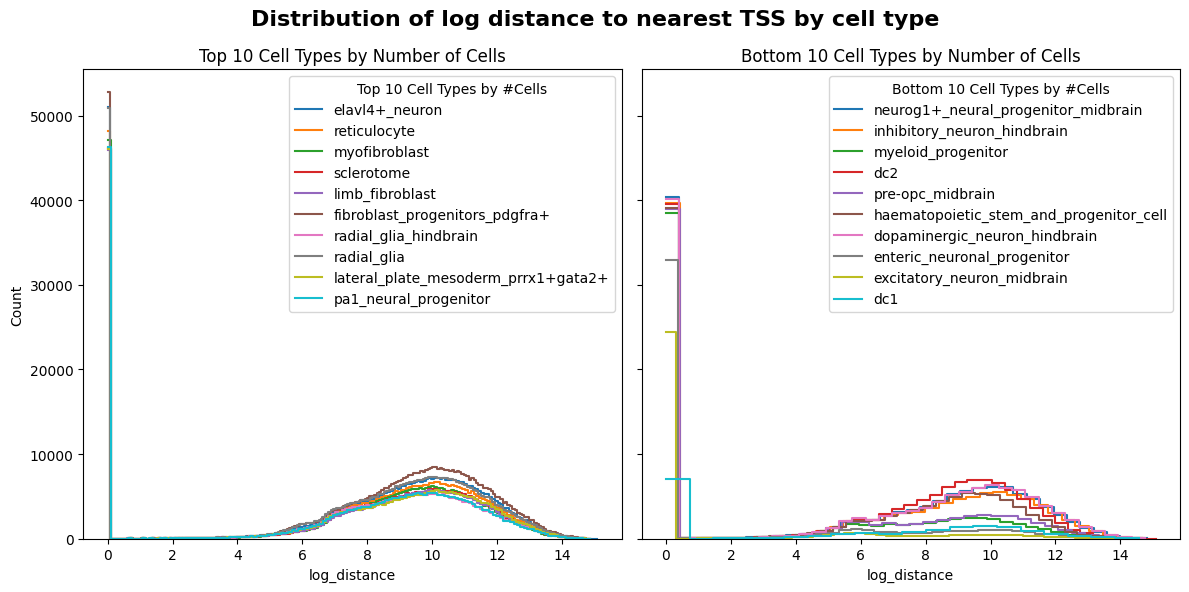

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ct in tqdm(celltypes[:10], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False)]
    sns.histplot(subset, x="log_distance", element="step", fill=False, label=ct, ax=ax1)
ax1.legend(celltypes[:10], title="Top 10 Cell Types by #Cells")
ax1.set_title("Top 10 Cell Types by Number of Cells")


for ct in tqdm(celltypes[-10:], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False)]
    sns.histplot(subset, x="log_distance", element="step", fill=False, label=ct, ax=ax2)
ax2.legend(celltypes[-10:], title="Bottom 10 Cell Types by #Cells")
ax2.set_title("Bottom 10 Cell Types by Number of Cells")

plt.suptitle("Distribution of log distance to nearest TSS by cell type", size=16, fontweight="bold")
plt.tight_layout()

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating peaks per cell type:   0%|          | 0/10 [00:00<?, ?it/s]

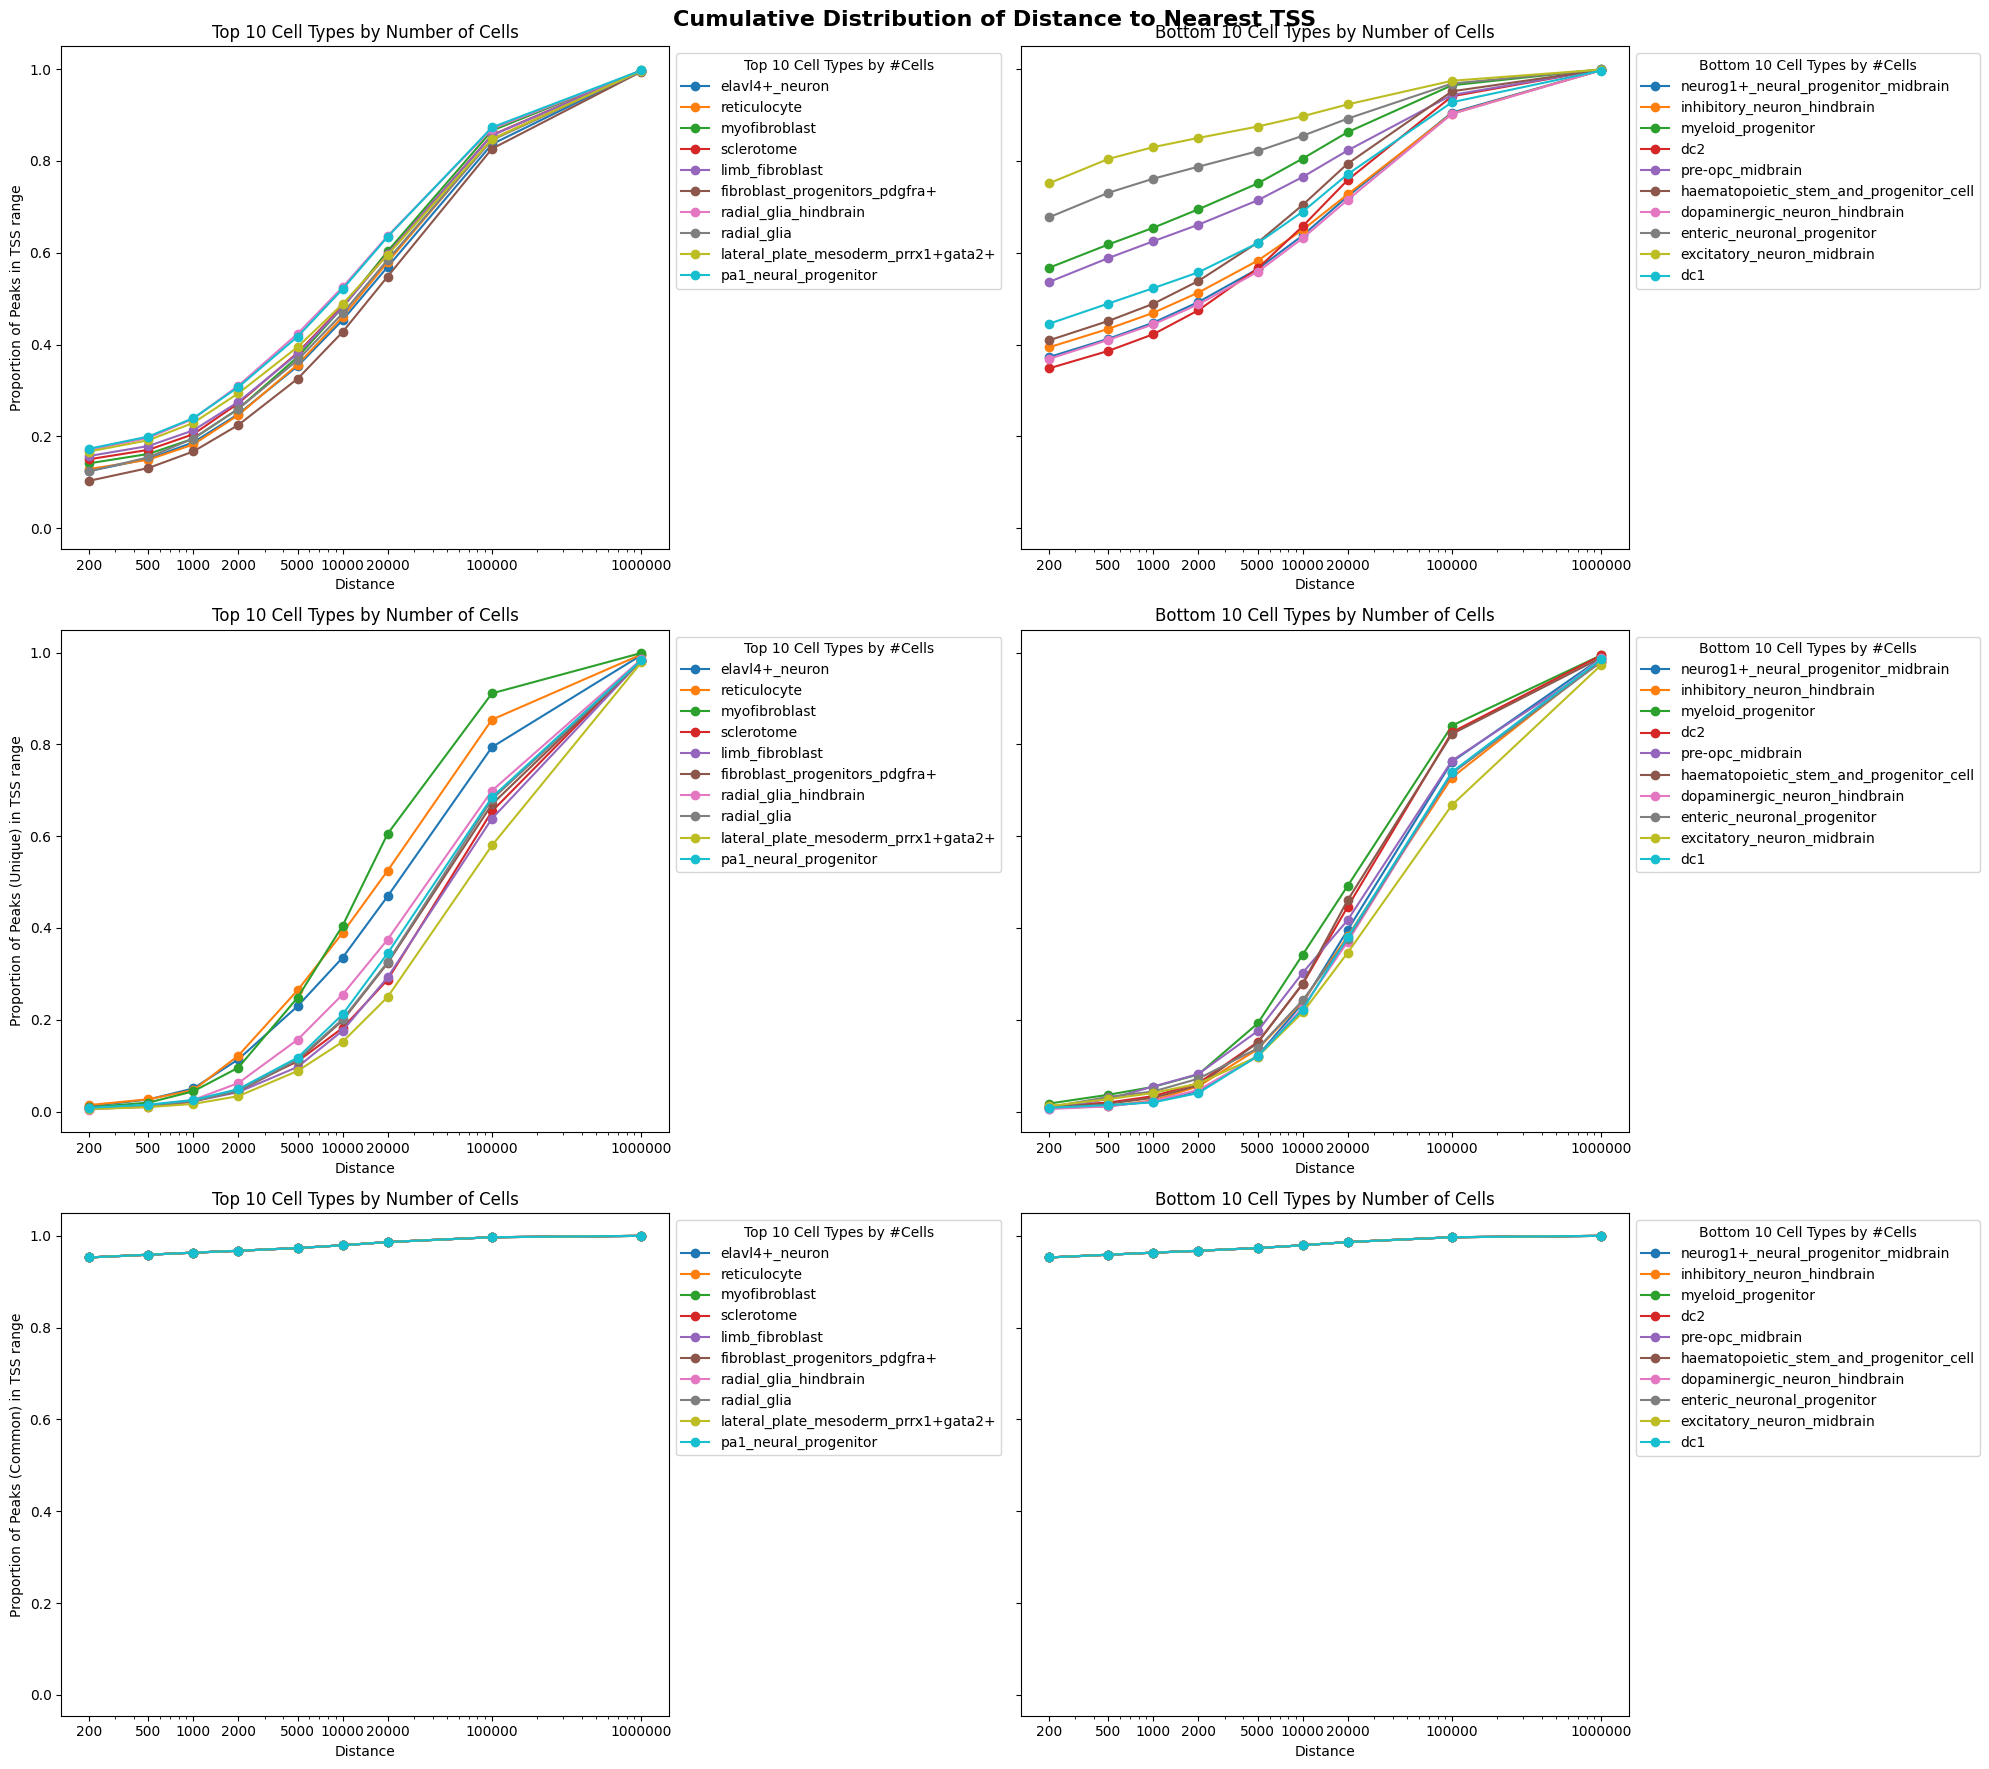

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18), sharey=True)

ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
distance = [200, 500, 1000, 2000, 5000, 10000, 20000, 100000, 1000000]

for ct in tqdm(celltypes[:10], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False)]
    ax1.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax1.legend(celltypes[:10], title="Top 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax1.set_title("Top 10 Cell Types by Number of Cells")
ax1.set_xscale("log")
ax1.set_xticks(ticks=distance, labels=distance)
ax1.set_xlabel("Distance")
ax1.set_ylabel("Proportion of Peaks in TSS range")


for ct in tqdm(celltypes[-10:], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False)]
    ax2.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax2.legend(celltypes[-10:], title="Bottom 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax2.set_title("Bottom 10 Cell Types by Number of Cells")
ax2.set_xscale("log")
ax2.set_xticks(ticks=distance, labels=distance)
ax2.set_xlabel("Distance")

for ct in tqdm(celltypes[:10], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False) & (peaks_tss.ct_count <= 3)]
    ax3.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax3.legend(celltypes[:10], title="Top 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax3.set_title("Top 10 Cell Types by Number of Cells")
ax3.set_xscale("log")
ax3.set_xticks(ticks=distance, labels=distance)
ax3.set_xlabel("Distance")
ax3.set_ylabel("Proportion of Peaks (Unique) in TSS range")


for ct in tqdm(celltypes[-10:], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False) & (peaks_tss.ct_count <= 3)]
    ax4.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax4.legend(celltypes[-10:], title="Bottom 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax4.set_title("Bottom 10 Cell Types by Number of Cells")
ax4.set_xscale("log")
ax4.set_xticks(ticks=distance, labels=distance)
ax4.set_xlabel("Distance")

for ct in tqdm(celltypes[:10], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False) & (peaks_tss.ct_count > 150)]
    ax5.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax5.legend(celltypes[:10], title="Top 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax5.set_title("Top 10 Cell Types by Number of Cells")
ax5.set_xscale("log")
ax5.set_xticks(ticks=distance, labels=distance)
ax5.set_xlabel("Distance")
ax5.set_ylabel("Proportion of Peaks (Common) in TSS range")


for ct in tqdm(celltypes[-10:], desc="Calculating peaks per cell type"):
    subset = peaks_tss[peaks_tss.celltypes.str.contains(ct, regex=False) & (peaks_tss.ct_count > 150)]
    ax6.plot(distance, [(subset.Distance <= d).mean() for d in distance], 'o-')
ax6.legend(celltypes[-10:], title="Bottom 10 Cell Types by #Cells",
           loc="upper left", bbox_to_anchor=(1, 1), ncols=1)
ax6.set_title("Bottom 10 Cell Types by Number of Cells")
ax6.set_xscale("log")
ax6.set_xticks(ticks=distance, labels=distance)
ax6.set_xlabel("Distance")

plt.suptitle("Cumulative Distribution of Distance to Nearest TSS", size=16, fontweight="bold")
plt.tight_layout()

## SCREEN overlap

In [28]:
overlaps = peaks.intersect_overlaps(screen_peaks)
overlaps.head()

,Chromosome,Start,End,Name,Score,Strand,Center,celltypes,ct_count
0,chr1,794885,795155,radial_glia_diencephalon_peak_3,0.097895,.,794945,radial_glia_diencephalon,1
1,chr1,804781,805061,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,804926,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833041,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1
2,chr1,833358,833520,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1
4,chr1,841711,842011,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,841923,megakaryocyte_progenitor,1


Add overlap indicator

In [29]:
peaks["screen_overlap"] = peaks.Name.isin(overlaps.Name.unique().tolist())
peaks.head()

,Chromosome,Start,End,Name,Score,Strand,Center,celltypes,ct_count,screen_overlap
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,794945,radial_glia_diencephalon,1,True
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,804926,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1,True
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,833287,wolffian_duct_epithelium,1,True
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,833908,megakaryocyte_progenitor,1,False
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,841923,megakaryocyte_progenitor,1,True


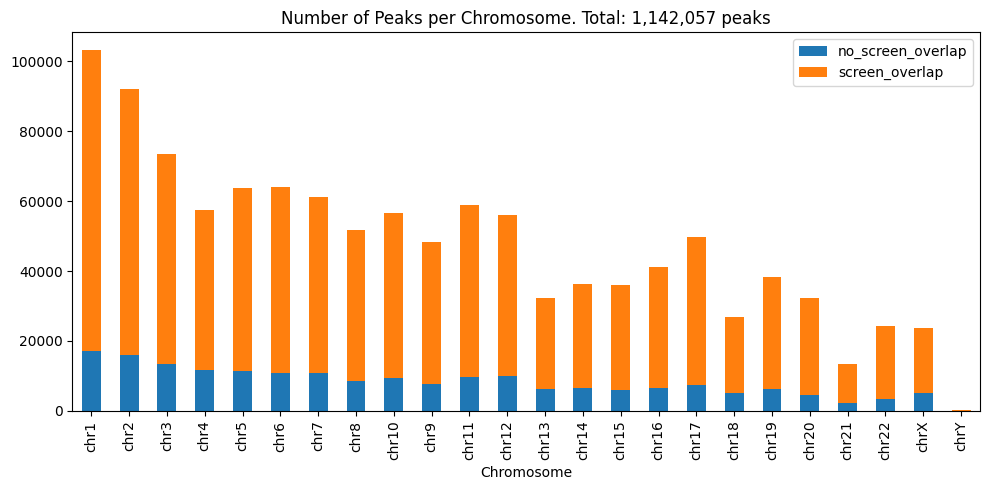

In [30]:
chr_counts = peaks.groupby(["Chromosome", "screen_overlap"]).agg({"Name": "count"}).unstack()
chr_counts.columns = ["no_screen_overlap", "screen_overlap"]
chr_counts.plot.bar(stacked=True, figsize=(10, 5))
plt.title(f'Number of Peaks per Chromosome. Total: {peaks.shape[0]:,} peaks')
plt.tight_layout()

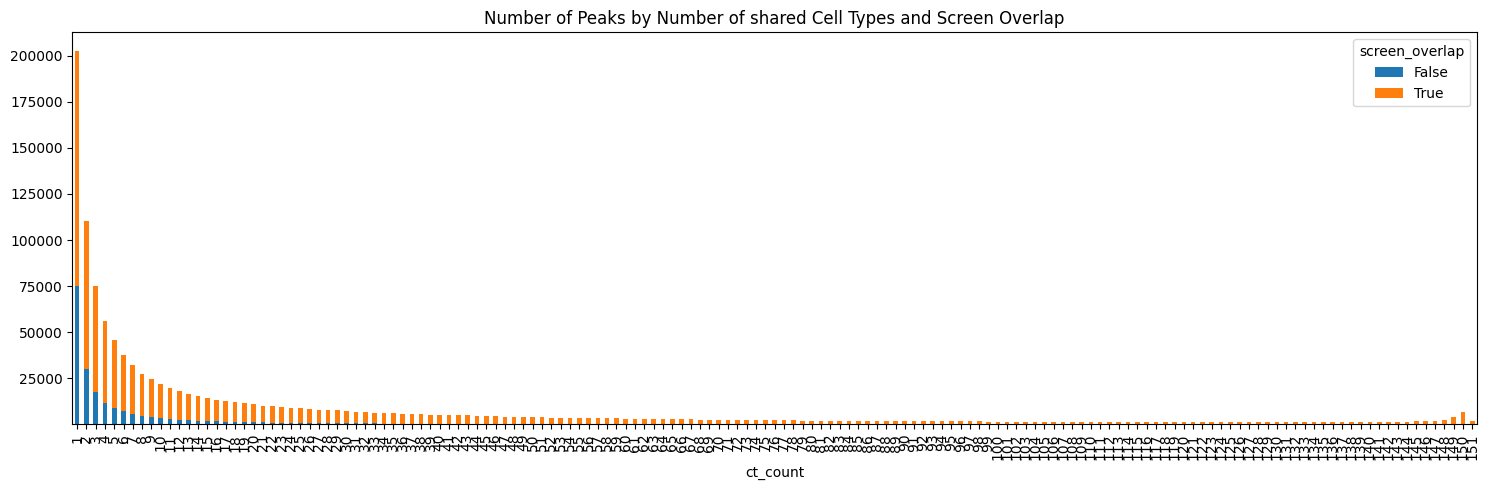

In [35]:
shared_ct_overlap = peaks.groupby(["ct_count"]).screen_overlap.value_counts().unstack()
shared_ct_overlap.plot.bar(stacked=True, figsize=(15, 5))
shared_ct_overlap.columns = ["no_screen_overlap", "screen_overlap"]
plt.title("Number of Peaks by Number of shared Cell Types and Screen Overlap")
plt.tight_layout()

In [32]:
# count the number of SCREEN overlapping peaks that are present in each cell type
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks[peaks["screen_overlap"]]["celltypes"].tolist()]))
counts = Counter(flat)
n_peaks_celltype_overlap = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks_overlap"]).set_index("celltype")

# count the number of SCREEN non-overlapping peaks that are present in each cell type
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks[~peaks["screen_overlap"]]["celltypes"].tolist()]))
counts = Counter(flat)
n_peaks_celltype_non_overlap = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks_non_overlap"]).set_index("celltype")

# count the number of SCREEN overlapping peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_overlap_counts = peaks[(peaks['ct_count'] == 1) & peaks["screen_overlap"]].celltypes.value_counts().to_frame(name="n_unique_overlap")

# count the number of SCREEN non-overlapping peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_non_overlap_counts = peaks[(peaks['ct_count'] == 1) & ~peaks["screen_overlap"]].celltypes.value_counts().to_frame(name="n_unique_non_overlap")

peak_counts = pd.concat([
    n_peaks_celltype_overlap,
    n_peaks_celltype_non_overlap,
    unique_peak_overlap_counts,
    unique_peak_non_overlap_counts,
    cell_counts,
    ], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique_overlap"] = peak_counts["n_unique_overlap"] / peak_counts["n_peaks_overlap"]
peak_counts["frc_unique_non_overlap"] = peak_counts["n_unique_non_overlap"] / peak_counts["n_peaks_non_overlap"]
peak_counts

,celltype,n_peaks_overlap,n_peaks_non_overlap,n_unique_overlap,n_unique_non_overlap,n_cells,frc_unique_overlap,frc_unique_non_overlap
0,elavl4+_neuron,385935,25863,91,47,29842,0.000236,0.001817
1,reticulocyte,369231,23599,108,62,21975,0.000292,0.002627
2,myofibroblast,326037,20194,92,73,19891,0.000282,0.003615
5,sclerotome,296861,19042,1651,809,15369,0.005562,0.042485
9,limb_fibroblast,282969,15808,510,228,12630,0.001802,0.014423
...,...,...,...,...,...,...,...,...
138,haematopoietic_stem_and_progenitor_cell,75567,4643,1911,2129,70,0.025289,0.458540
129,dopaminergic_neuron_hindbrain,88783,5652,1572,1976,56,0.017706,0.349611
148,enteric_neuronal_progenitor,30714,625,220,274,31,0.007163,0.438400
149,excitatory_neuron_midbrain,18363,443,141,213,9,0.007678,0.480813


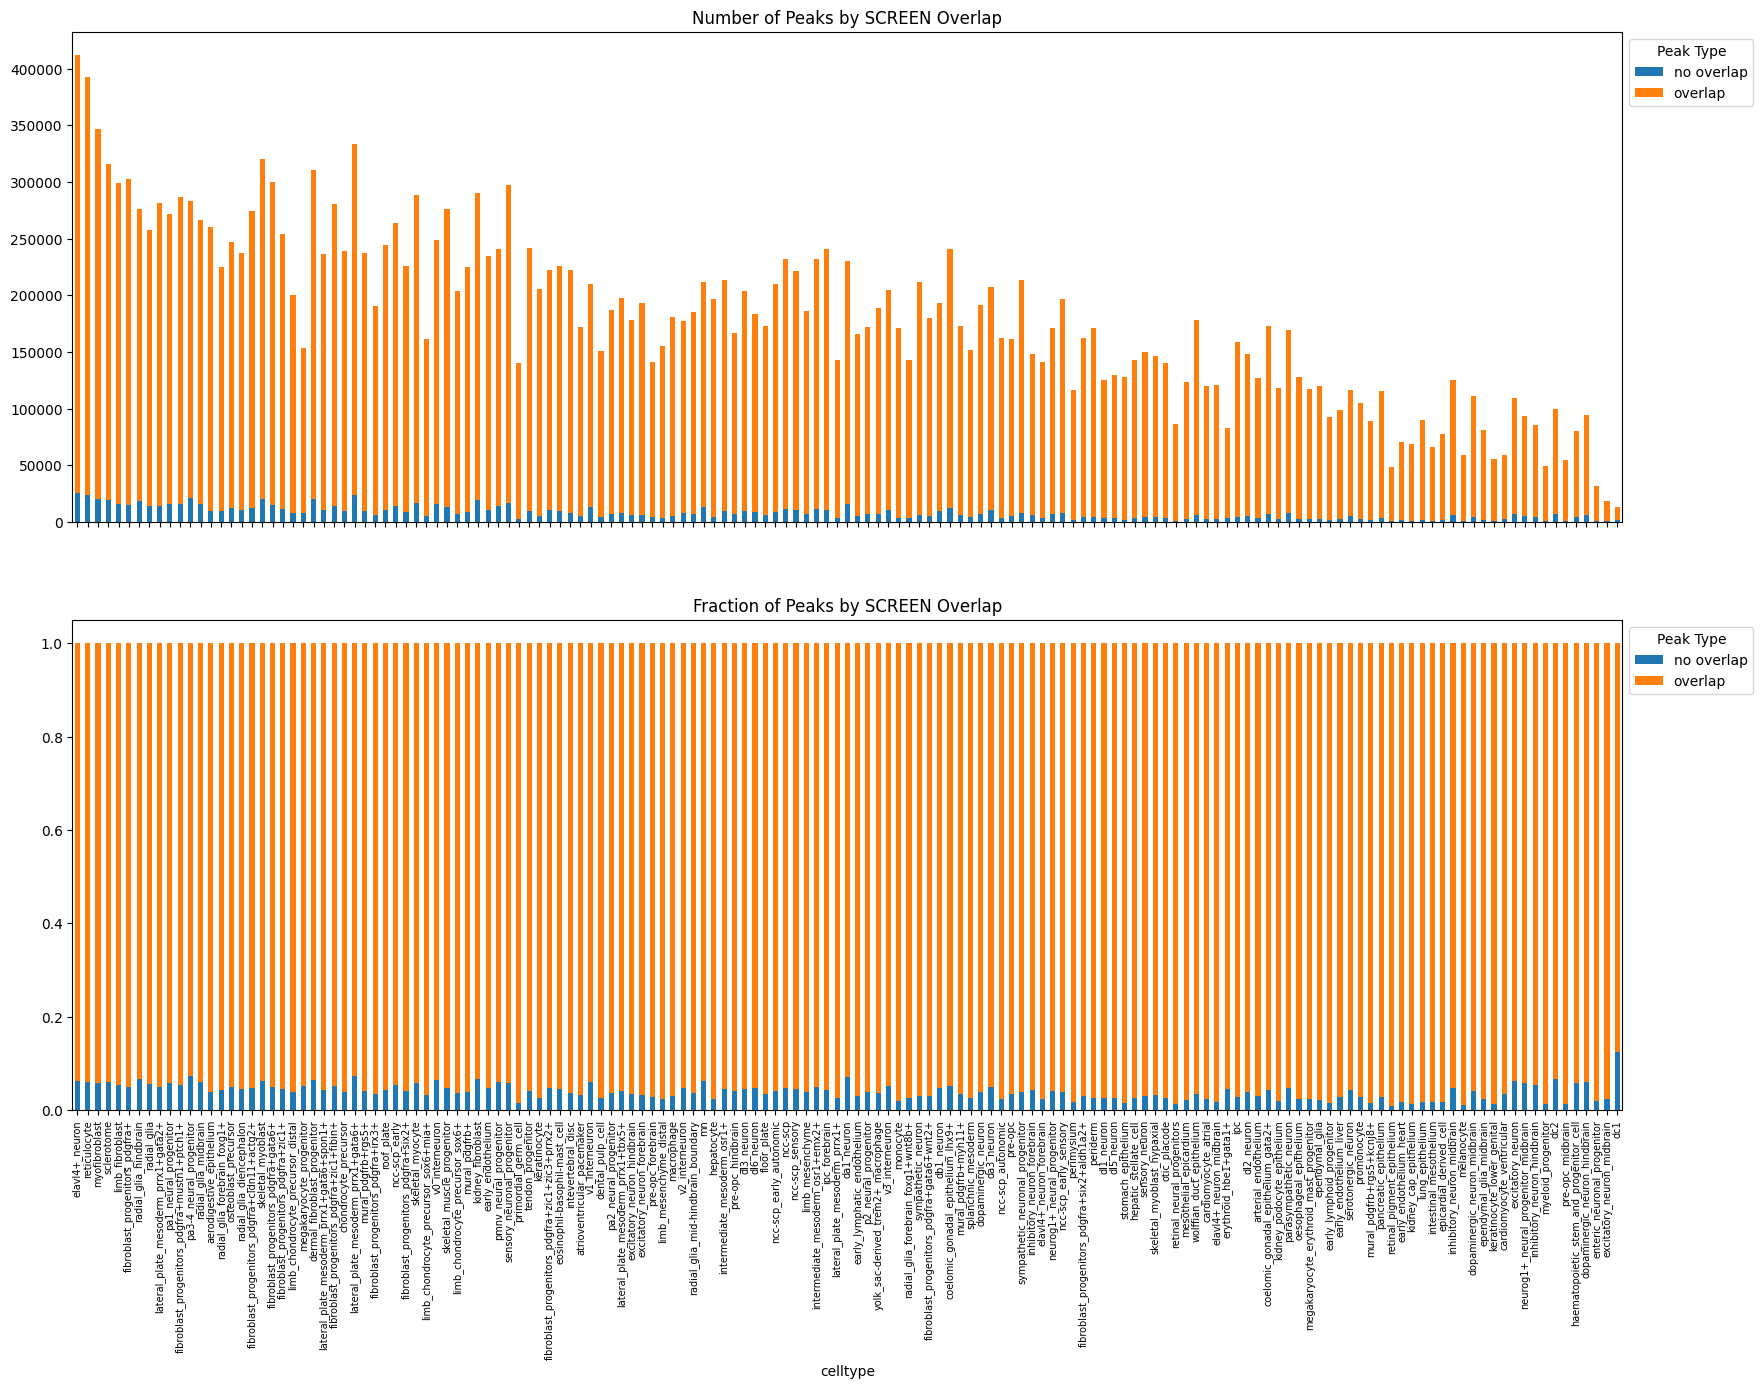

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

counts = peak_counts[["celltype", "n_peaks_non_overlap", "n_peaks_overlap"]].set_index("celltype")
counts.columns = ["no overlap", "overlap"]
fractions = counts / counts.sum(axis=1).values.reshape(-1, 1)

counts.plot.bar(stacked=True, ax=axes[0])
fractions.plot.bar(stacked=True, ax=axes[1])

sns.move_legend(axes[0], loc="upper left", bbox_to_anchor=(1, 1), title="Peak Type")
sns.move_legend(axes[1], loc="upper left", bbox_to_anchor=(1, 1), title="Peak Type")
axes[0].set_title("Number of Peaks by SCREEN Overlap")
axes[1].set_title("Fraction of Peaks by SCREEN Overlap")
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=7)
plt.show()

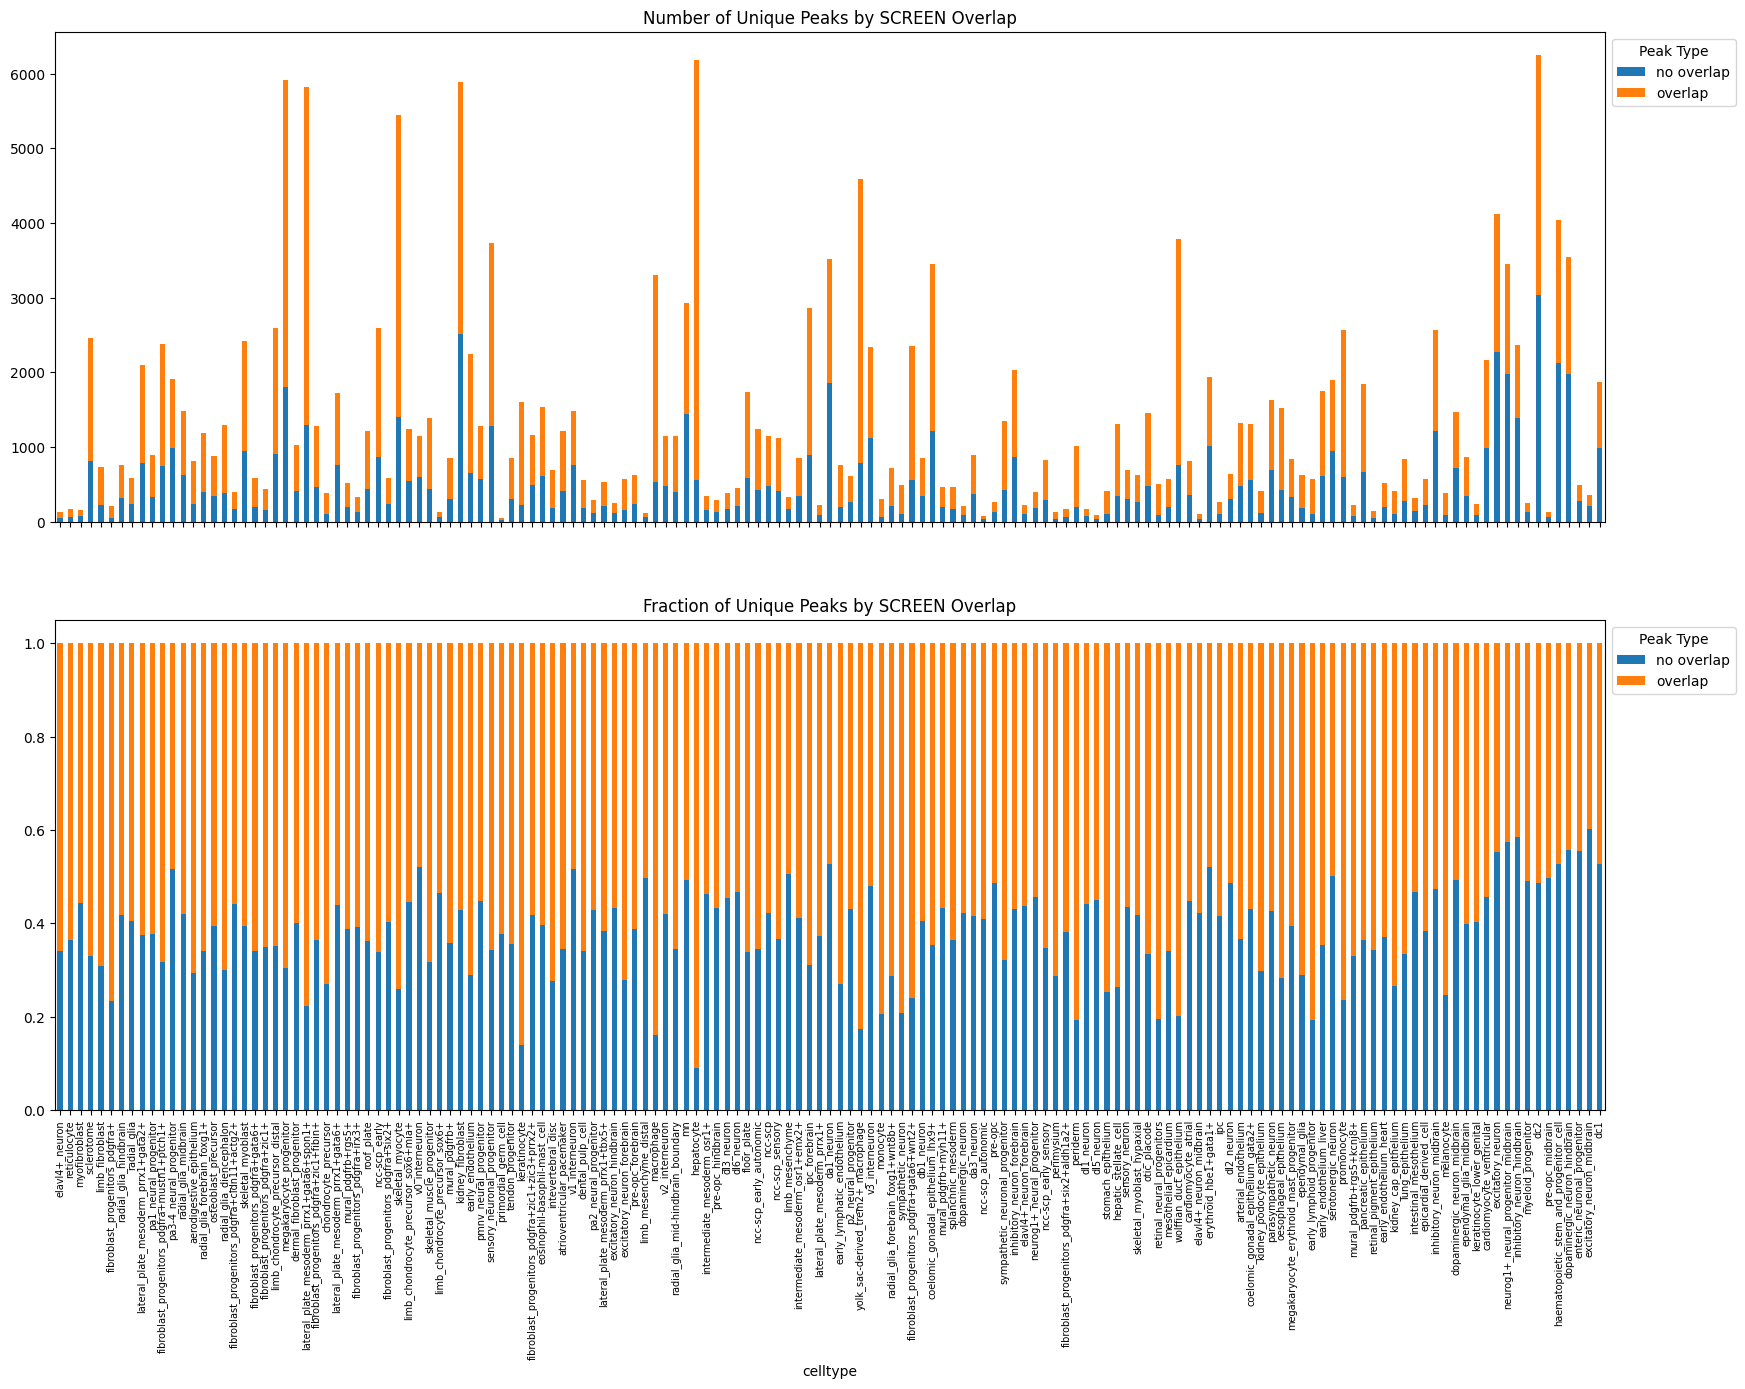

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharex=True)

counts = peak_counts[["celltype", "n_unique_non_overlap", "n_unique_overlap"]].set_index("celltype")
counts.columns = ["no overlap", "overlap"]
fractions = counts / counts.sum(axis=1).values.reshape(-1, 1)

counts.plot.bar(stacked=True, ax=axes[0])
fractions.plot.bar(stacked=True, ax=axes[1])

sns.move_legend(axes[0], loc="upper left", bbox_to_anchor=(1, 1), title="Peak Type")
sns.move_legend(axes[1], loc="upper left", bbox_to_anchor=(1, 1), title="Peak Type")
axes[0].set_title("Number of Unique Peaks by SCREEN Overlap")
axes[1].set_title("Fraction of Unique Peaks by SCREEN Overlap")
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=7)
plt.show()